In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [9]:
data = {
    "YearsExperience": [
        0.3, 0.7, 1.1, 1.4, 1.8, 2.2, 2.6, 2.9, 3.3, 3.7,
        4.1, 4.4, 4.8, 5.2, 5.6, 5.9, 6.3, 6.7, 7.1, 7.4,
        7.8, 8.2, 8.6, 8.9, 9.3
    ],
    "Salary": [
        16000, 20000, 24000, 27000, 31000, 35000, 39000, 42000, 46000, 50000,
        54000, 58000, 62000, 67000, 72000, 76000, 81000, 86000, 91000, 96000,
        101000, 107000, 113000, 119000, 125000
    ]
}
df = pd.DataFrame(data)
print(df.head())

   YearsExperience  Salary
0              0.3   16000
1              0.7   20000
2              1.1   24000
3              1.4   27000
4              1.8   31000


In [10]:
X = df[['YearsExperience']]
y = df['Salary']

In [11]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42
)

In [12]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [13]:
print("Intercept (b0):",model.intercept_)
print("Slope (b1):", model.coef_[0])

Intercept (b0): 8275.844194575708
Slope (b1): 11869.033121611596


In [14]:
y_pred = model.predict(X_test)

In [15]:
comparison = pd.DataFrame({
    'Actual Salary': y_test,
    'Predicted Salary': y_pred
})
comparison

,Actual Salary,Predicted Salary
8,46000,47443.653496
16,81000,83050.752861
0,16000,11836.554131
23,119000,113910.238977
11,58000,60499.589930


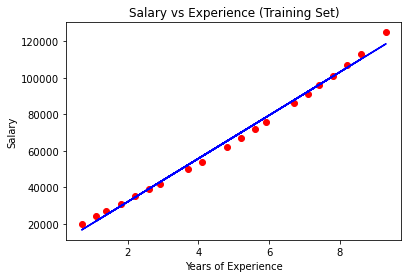

In [17]:
plt.scatter(X_train.values, y_train.values, color='red')
plt.plot(X_train.values, model.predict(X_train), color='blue')
plt.title("Salary vs Experience (Training Set)")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.show()

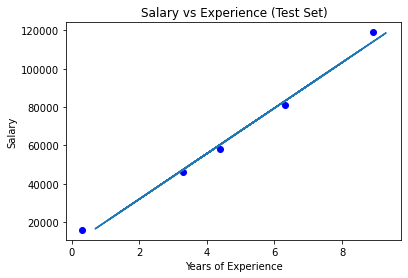

In [19]:
plt.scatter(X_test.values, y_test.values, color='blue')
plt.plot(X_train.values, model.predict(X_train))
plt.title("Salary vs Experience (Test Set)")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.show()

In [20]:
new_salary = model.predict([[5]])
print("Predicted Salary for 5 years experience:", new_salary[0])

Predicted Salary for 5 years experience: 67621.0098026337


C:\ProgramData\Anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [21]:
from sklearn.metrics import r2_score
print("R2 Score:", r2_score(y_test, y_pred))

R2 Score: 0.9906695180153628


In [25]:
from sklearn.preprocessing import PolynomialFeatures

In [28]:
# Polynomial transformation
poly = PolynomialFeatures(degree=2)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Train model on polynomial data (IMPORTANT)
model = LinearRegression()
model.fit(X_train_poly, y_train)

# Now prediction will work
y_pred = model.predict(X_test_poly)

In [29]:
X_grid = np.linspace(min(X.values), max(X.values), 100).reshape(-1,1)
X_grid_poly = poly.transform(X_grid)

C:\ProgramData\Anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


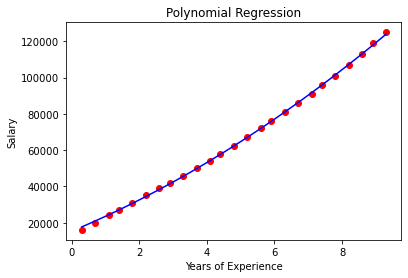

In [30]:
plt.scatter(X.values, y.values, color='red')
plt.plot(X_grid, model.predict(X_grid_poly), color='blue')
plt.title("Polynomial Regression")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.show()

In [32]:
new_salary_poly = model.predict(poly.transform([[5]]))
print("Predicted Salary for 5 years experience:", new_salary_poly[0])
# R2 Score
from sklearn.metrics import r2_score
print("R2 Score:", r2_score(y_test, y_pred))

Predicted Salary for 5 years experience: 64676.7955472263
R2 Score: 0.9992285330774462


C:\ProgramData\Anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
